In [2]:
import os

os.environ['CUDA_VISIBLE_DEVICES'] = '-1' # don't use GPU
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' #omit info

from learnMSA.align import AlignmentModel
from learnMSA.util import SequenceDataset
from learnMSA.util.visualize import plot_phmm

2026-07-09 14:13:10.908160: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783599190.924890  302386 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783599190.930279  302386 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783599190.943732  302386 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783599190.943744  302386 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783599190.943746  302386 computation_placer.cc:177] computation placer alr

In [5]:
layer = alignment_model.model.phmm_layer
layer.joint_emitter.matrix()[0, :24, 7]

<tf.Tensor: shape=(24,), dtype=float32, numpy=
array([7.37217779e-05, 1.03880055e-02, 1.13295475e-02, 3.51742329e-03,
       1.15727426e-05, 6.94318005e-05, 1.08581735e-03, 7.36559232e-05,
       2.85205679e-05, 2.08942976e-04, 2.13895715e-03, 8.27513821e-03,
       4.37614948e-01, 7.01159413e-04, 8.67832527e-02, 3.83085990e-03,
       4.72505577e-03, 2.64600432e-03, 1.09303696e-02, 4.19208594e-03,
       1.44777354e-02, 2.55942368e-03, 3.33171804e-03, 1.16227043e-03],
      dtype=float32)>

In [6]:
layer.joint_emitter.AB_matrix()[0]

<tf.Tensor: shape=(56, 43), dtype=float32, numpy=
array([[ 1.593918  ,  0.6054512 ,  1.2272078 , ..., -0.8449387 ,
        -0.17340517, -0.18850301],
       [-0.5843888 , -0.17215882, -0.18717977, ...,  1.2474469 ,
         0.5816772 ,  0.6052486 ],
       [ 0.3761833 ,  1.3692646 ,  1.9098476 , ..., -0.20222938,
         1.5637999 , -0.53152615],
       ...,
       [-0.0092895 ,  0.01177613, -0.01167384, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]], dtype=float32)>

2026-07-09 14:13:13.232163: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


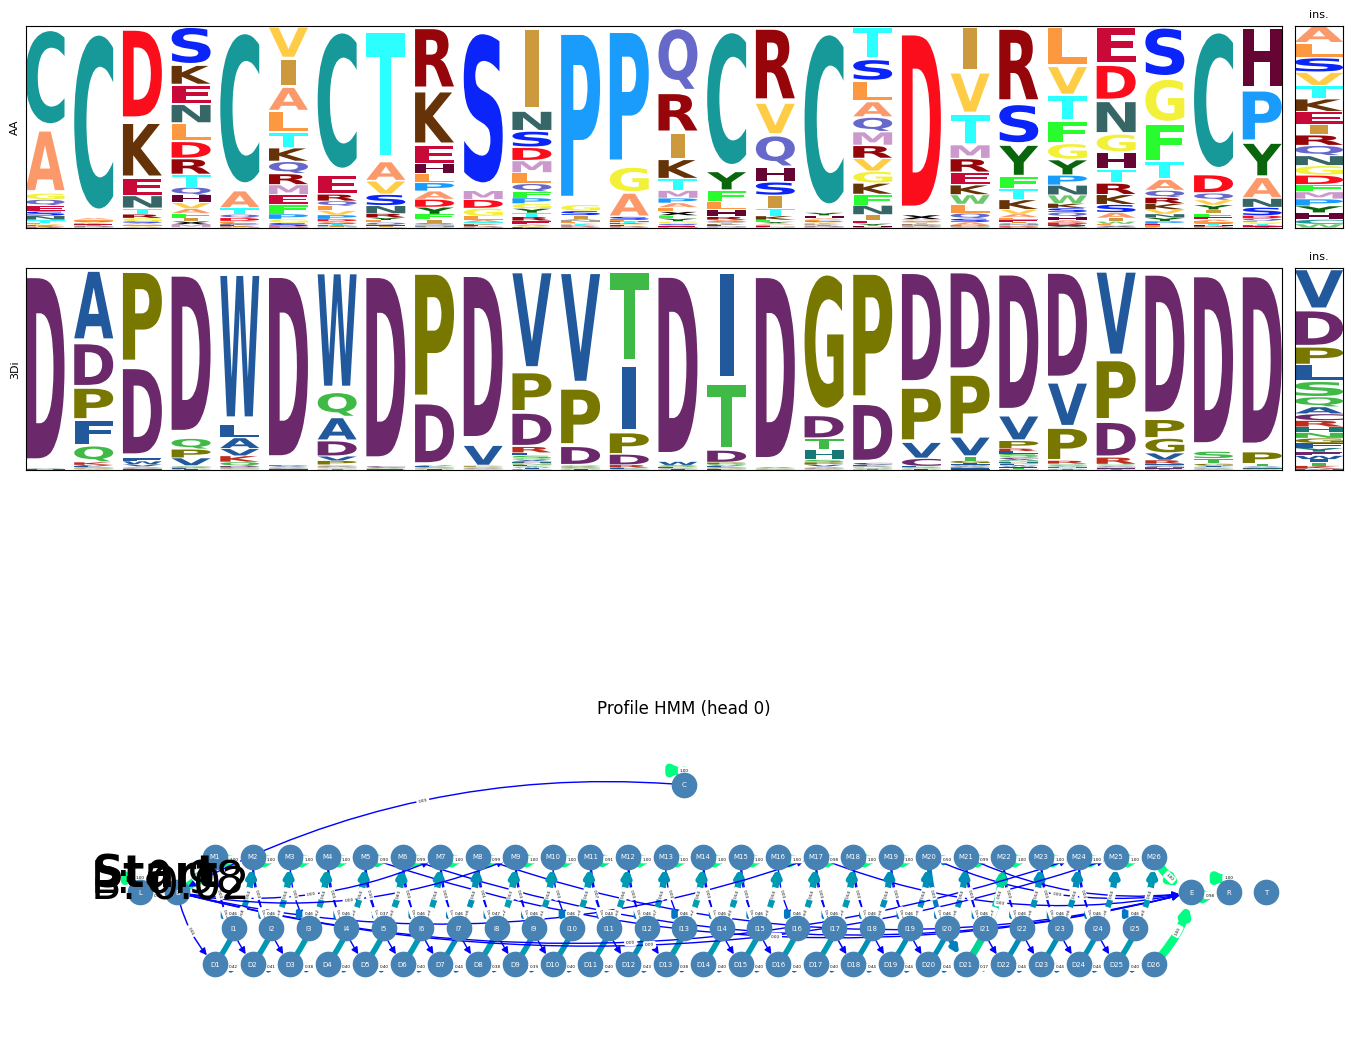

In [3]:
# Model built with:
# learnMSA --from_msa egf.ref
# --skip_training --no_noise --save_model egf.model
model_path = "../../snakeMSA/outputs/small_benchmark/learnMSA_3di_joint_low_rank_1/workdirs/bowman.vie/bowman.model"
data_path = "../../snakeMSA/data/homfam/unaligned/bowman.vie"

data = SequenceDataset(data_path)
alignment_model = AlignmentModel.load(model_path, data)

fig=plot_phmm(alignment_model.model.phmm_layer, head = 0, fast_mode = True)

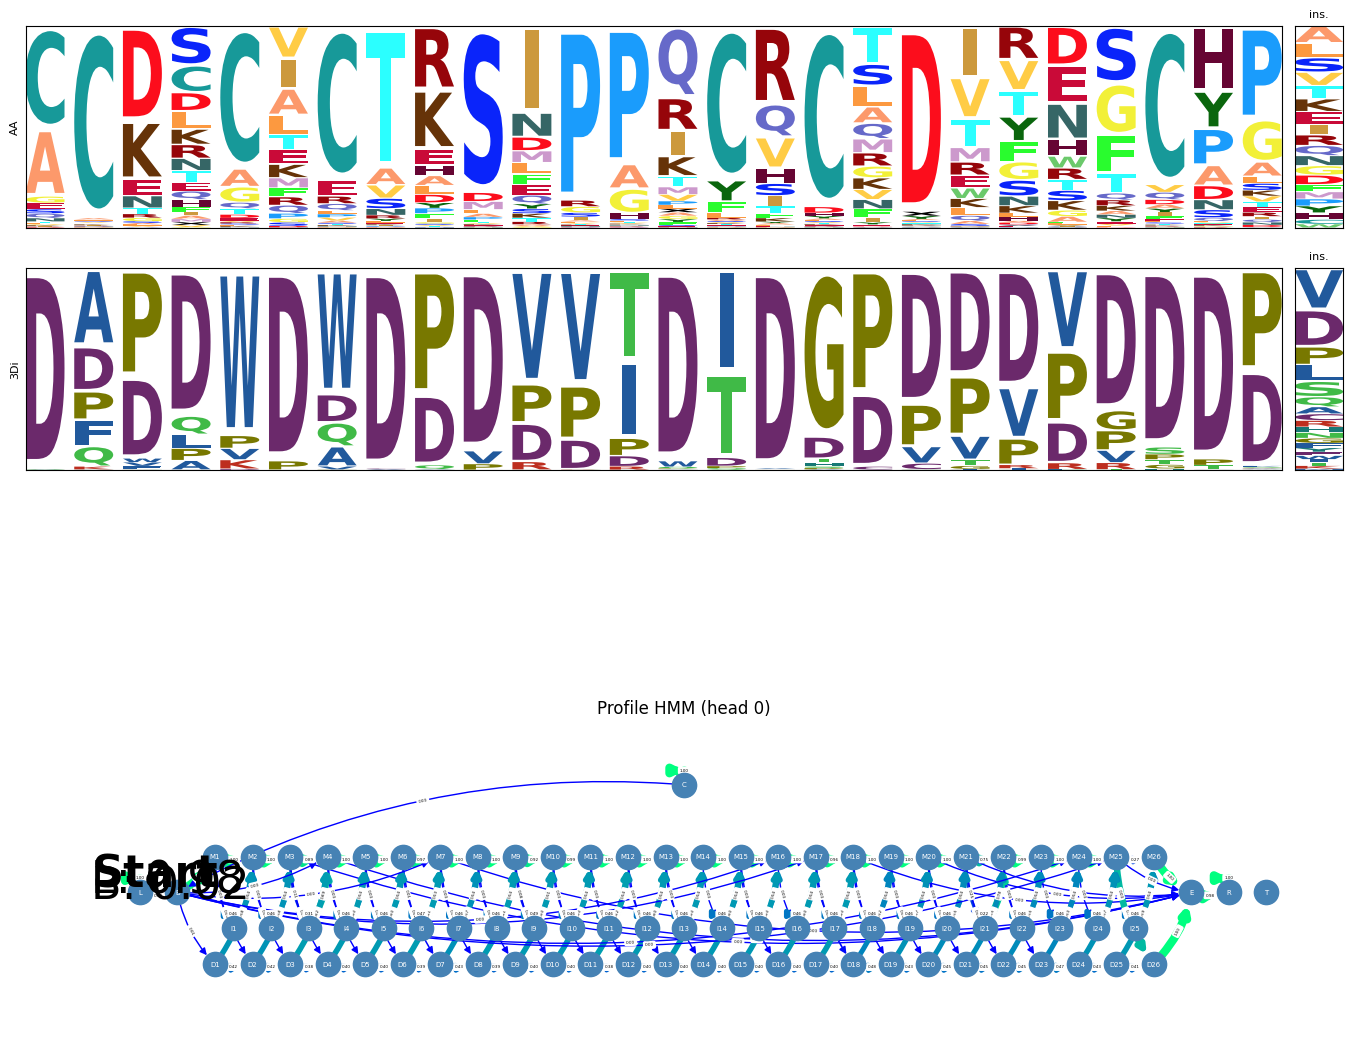

In [5]:
# Model built with:
# learnMSA --from_msa egf.ref
# --skip_training --no_noise --save_model egf.model
model_path = "../../snakeMSA/outputs/small_benchmark/learnMSA_3di_joint_low_rank_5/workdirs/bowman.vie/bowman.model"
data_path = "../../snakeMSA/data/homfam/unaligned/bowman.vie"

data = SequenceDataset(data_path)
alignment_model = AlignmentModel.load(model_path, data)

fig=plot_phmm(alignment_model.model.phmm_layer, head = 0, fast_mode = True)

In [ ]:
fig.savefig("egf_phmm.pdf", bbox_inches="tight") # type: ignore